In [15]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LinearRegression

from numpy.linalg import qr

In [16]:
def define_data_set_old(num_tasks, T):

    x_dataset = torch.zeros([num_tasks, 4, T]); y_dataset = []; 
    
    #coin flips for ground truth
    context_ = 2*np.random.rand(num_tasks) - 1           #-1 = motion context; +1 = color context
    context = 2*((context_<0.0).astype(int))-1      #-1 = motion context; +1 = color context
    
    color_ = 2*np.random.rand(num_tasks) - 1             #-1 = blue; +1 = red
    color = 2*((color_<0.0).astype(int)) - 1               #-1 = blue; +1 = red
    
    motion_ = 2*np.random.rand(num_tasks) - 1 #0 = left; 1 = right
    motion = 2*((motion_<0.0).astype(int)) - 1 #0 = left; 1 = right

    y_dataset_full = torch.cat((torch.tensor(motion).unsqueeze(1), torch.tensor(color).unsqueeze(1), torch.tensor(context).unsqueeze(1)), dim=1)
    
    for n in range(num_tasks):

        if context[n] == -1:
            y_dataset.append(motion[n])        
        else:
            y_dataset.append(color[n])

        motion_signal = motion_[n] + motion_[n]/10*np.random.randn(T)        
        color_signal = color_[n] + color_[n]/10*np.random.randn(T)        

        motion_signal = 0.2*motion_signal; color_signal = 0.2*color_signal;
        
        x_dataset[n,0,:] = torch.tensor(motion_signal)
        x_dataset[n,1,:] = torch.tensor(color_signal)
        
        if context[n] == -1:
            x_dataset[n,2,:] = torch.tensor([1]*T)
            x_dataset[n,3,:] = torch.tensor([0]*T)
        else:
            x_dataset[n,2,:] = torch.tensor([0]*T)
            x_dataset[n,3,:] = torch.tensor([1]*T)

    y_dataset = torch.tensor(y_dataset)

    return x_dataset, y_dataset, y_dataset_full

In [17]:
def define_data_set(num_tasks, T):
    x_dataset = torch.zeros([num_tasks, 4, T])
    y_dataset = torch.zeros([num_tasks, T])
    
    # ground truth
    context_ = 2*np.random.rand(num_tasks) - 1
    context = 2*((context_<0.0).astype(int)) - 1

    color_ = 2*np.random.rand(num_tasks) - 1
    color = 2*((color_<0.0).astype(int)) - 1

    motion_ = 2*np.random.rand(num_tasks) - 1
    motion = 2*((motion_<0.0).astype(int)) - 1

    y_dataset_full = torch.cat((torch.tensor(motion).unsqueeze(1), torch.tensor(color).unsqueeze(1), torch.tensor(context).unsqueeze(1)), dim=1)

    fix_end = int(0.2 * T)
    stim_end = int(0.8 * T)

    for n in range(num_tasks):
        # target per timestep
        if context[n] == -1:
            y_dataset[n, fix_end:stim_end] = motion[n]
            #y_dataset[n] = motion[n]
        else:
            y_dataset[n, fix_end:stim_end] = color[n]
            #y_dataset[n] = color[n]

        # coherence
        coh = np.random.choice([0.05, 0.1, 0.2])  # slightly stronger
        # baseline noise
        motion_signal = 0.001*np.random.randn(T)
        color_signal  = 0.001*np.random.randn(T)
        # add stimulus
        motion_signal[fix_end:stim_end] += motion_[n] * coh
        color_signal[fix_end:stim_end]  += color_[n]  * coh

        x_dataset[n,0,:] = torch.tensor(motion_signal)
        x_dataset[n,1,:] = torch.tensor(color_signal)

        # context input
        if context[n] == -1:
            x_dataset[n,2,:] = 1.0
            x_dataset[n,3,:] = 0.0
        else:
            x_dataset[n,2,:] = 0.0
            x_dataset[n,3,:] = 1.0

    return x_dataset, y_dataset, y_dataset_full



In [18]:
x_dataset, y_dataset, y_dataset_full = define_data_set(10000, 750)
print("training data shapes", x_dataset.shape, y_dataset.shape)
training_dataset = TensorDataset(x_dataset, y_dataset)
training_data = DataLoader(training_dataset, batch_size=50, shuffle=True)

x_dataset2, y_dataset2, y_dataset_full2 = define_data_set(1000, 750)
print("training data shapes", x_dataset.shape, y_dataset.shape)
testing_dataset = TensorDataset(x_dataset2, y_dataset2)
testing_data = DataLoader(testing_dataset, batch_size=len(x_dataset2), shuffle=False)


training data shapes torch.Size([10000, 4, 750]) torch.Size([10000, 750])
training data shapes torch.Size([10000, 4, 750]) torch.Size([10000, 750])


Text(0, 0.5, 'y output (ground truth)')

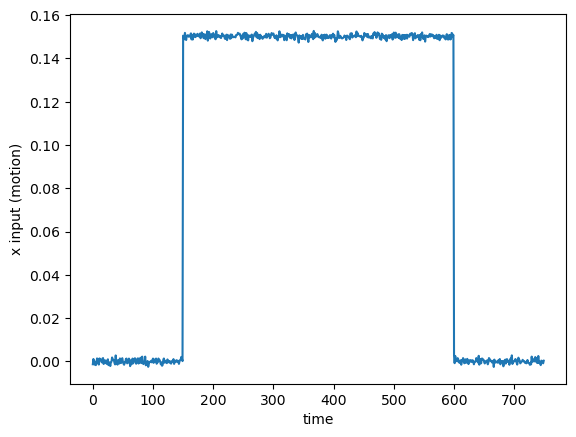

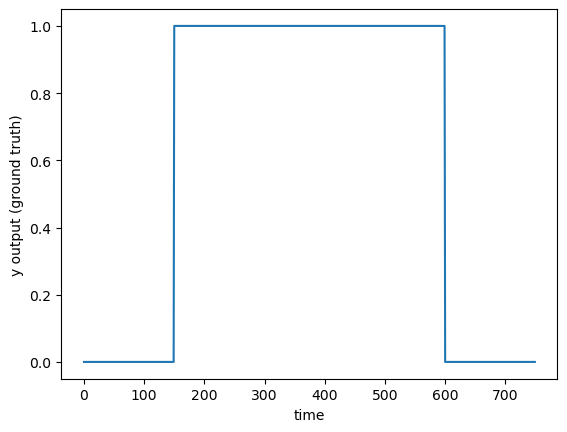

In [19]:
plt.figure()
plt.plot(x_dataset[1,0,:])
plt.xlabel("time")
plt.ylabel("x input (motion)")

plt.figure()
plt.plot(y_dataset[0,:])
plt.xlabel("time")
plt.ylabel("y output (ground truth)")


In [20]:
class RNN_neuro(nn.Module):
    
     def __init__(self, input_size=4, hidden_size=100, output_size = 1, batchsize = 50, dt=1, **kwargs):
        super().__init__()
         
        self.J_weights = nn.Parameter(1.5*torch.randn(hidden_size, hidden_size)/np.sqrt(hidden_size), requires_grad=True)
        self.nonlinear_fn = nn.Tanh()
    
        self.fc_in = nn.Linear(input_size, hidden_size)
        self.fc_out = nn.Linear(hidden_size, output_size)
        self.bias = nn.Parameter(torch.randn(hidden_size), requires_grad = True)

        self.std = 0.1
         
        self.tau = 10;
        self.dt = 1
        self.T = 750

        self.hidden_size = hidden_size
         
     def forward(self, input_):

        input_ = input_.float()
        batchsize = len(input_)
         
        h = torch.zeros(batchsize, self.hidden_size, device=input_.device)
        r = self.nonlinear_fn(h)

        all_h = []; all_r = []; 
        all_z = [];

        for t in range(self.T):
            temp = self.fc_in(input_[:,:,t]) + self.bias
            noise = self.std*torch.randn(batchsize, self.hidden_size) 

            h = h + self.dt/self.tau * (-h + r @ self.J_weights.T + temp + noise)
            r = self.nonlinear_fn(h)
            out = self.fc_out(r)

            all_h.append(h); all_r.append(r); 
            all_z.append(out)

        all_h = torch.stack(all_h, dim=2)
        all_r = torch.stack(all_r, dim=2)
        all_z = torch.stack(all_z, dim=2)
         
        return all_z, all_h, all_r

In [21]:
model = RNN_neuro()
model.float()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()   # Mante uses MSE on final output

In [22]:
def train_model(model, training_data, num_epochs=5, batchsize=50, lr=1e-3):

    epoch_loss_arr = []
    epoch_acc_arr = []
    y_arr = []; X_arr = [];
    z_final_arr = []; r_final_arr = []; h_final_arr = [];
    for epoch in range(num_epochs):

        epoch_loss = 0
        epoch_acc = 0
        epoch_total = 0
        for bid, batch in enumerate(training_data):

            X, y = batch
            batchsize, n_features, T = X.shape
            labels = y[:,int(T*0.5)]
            
            # forward pass
            all_z, all_h, all_r = model(X)
            
            # final output at last time step, shape (batch, 1)
            z_final = all_z[:, 0, int(T*0.8) - 1]

            optimizer.zero_grad()
            # MSE loss target needs shape (batch,)
            #loss = loss_fn(all_z[:,0,:750], y.float())
            loss = loss_fn(all_z[:,0,int(T*0.2):int(T*0.8)], y[:,int(T*0.2):int(T*0.8)].float())
            
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            
            preds = (z_final > 0).long()*2 - 1
            correct = (preds == labels).sum().item()
            #correct = (preds == y).sum().item()
            epoch_acc += correct
            epoch_total += batchsize

            epoch_loss_arr.append(loss)
            epoch_acc_arr.append(float(correct)/batchsize)
            X_arr.append(X); y_arr.append(labels);

            z_final_arr.append(all_z); h_final_arr.append(all_h); r_final_arr.append(all_r);
            
            print(bid, correct/batchsize)
            
        epoch_acc = epoch_acc / epoch_total
        print(f"Epoch {epoch+1:3d}/{num_epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.2f}%")
        
    z_final_arr = torch.stack(z_final_arr).view(-1, model.T); 
    h_final_arr = torch.stack(h_final_arr).view(-1, model.hidden_size, model.T); 
    r_final_arr = torch.stack(r_final_arr).view(-1, model.hidden_size, model.T); 
    X_arr = torch.stack(X_arr); y_arr = torch.stack(y_arr).flatten()

    print("r_final_arr shapes etc", r_final_arr.shape, h_final_arr.shape, z_final_arr.shape)

    return epoch_loss_arr, epoch_acc_arr, X_arr, y_arr, h_final_arr, r_final_arr, z_final_arr

In [23]:
def test_model(model, testing_data):

    for bid, batch in enumerate(testing_data):

        X, y = batch
        batchsize, n_features, T = X.shape
        labels = y[:,int(T*0.5)]
        print("batchsize", batchsize)

        # forward pass
        all_z, all_h, all_r = model(X)
        
        # final output at last time step, shape (batch, 1)
        z_final = all_z[:, 0, int(T*0.8) - 1]

        #compute testing loss
        loss = loss_fn(all_z[:,0,int(T*0.2):int(T*0.8)], y[:,int(T*0.2):int(T*0.8)].float())


        preds = torch.sign(z_final)
        correct = (preds == y[:,int(T*0.5)]).sum().item()
        accuracy = correct/batchsize

    print(f"Testing loss is {loss.item()} and accuracy {accuracy*100}")
    return X, labels, all_r, all_h

In [24]:
epoch_loss, epoch_acc, X_arr, y_arr, h_final_arr, r_final_arr, z_final_arr = train_model(model, training_data)

0 0.58
1 0.64
2 0.54
3 0.44
4 0.58
5 0.52
6 0.56
7 0.58
8 0.52
9 0.5
10 0.58
11 0.46
12 0.42
13 0.58
14 0.66
15 0.74
16 0.62
17 0.8
18 0.54
19 0.7
20 0.38
21 0.64
22 0.42
23 0.44
24 0.4
25 0.44
26 0.56
27 0.44
28 0.38
29 0.56
30 0.46
31 0.58
32 0.68
33 0.7
34 0.6
35 0.48
36 0.5
37 0.52
38 0.44
39 0.56
40 0.52
41 0.56
42 0.8
43 0.64
44 0.6
45 0.64
46 0.56
47 0.5
48 0.78
49 0.7
50 0.48
51 0.58
52 0.58
53 0.6
54 0.5
55 0.62
56 0.6
57 0.46
58 0.66
59 0.72
60 0.78
61 0.54
62 0.56
63 0.64
64 0.68
65 0.6
66 0.64
67 0.66
68 0.62
69 0.54
70 0.6
71 0.56
72 0.62
73 0.6
74 0.56
75 0.84
76 0.8
77 0.7
78 0.64
79 0.68
80 0.62
81 0.6
82 0.62
83 0.64
84 0.82
85 0.8
86 0.64
87 0.72
88 0.8
89 0.68
90 0.62
91 0.72
92 0.88
93 0.72
94 0.8
95 0.68
96 0.66
97 0.8
98 0.68
99 0.78
100 0.74
101 0.76
102 0.76
103 0.88
104 0.64
105 0.7
106 0.78
107 0.8
108 0.86
109 0.86
110 0.76
111 0.8
112 0.7
113 0.66
114 0.62
115 0.76
116 0.6
117 0.58
118 0.78
119 0.88
120 0.86
121 0.8
122 0.7
123 0.62
124 0.66
125 0.72
126 0.7

In [26]:
X, y, all_r, all_h = test_model(model, testing_data)
X.shape, y.shape, all_r.shape, all_h.shape

batchsize 1000
Testing loss is 0.18258419632911682 and accuracy 96.89999999999999


(torch.Size([1000, 4, 750]),
 torch.Size([1000]),
 torch.Size([1000, 100, 750]),
 torch.Size([1000, 100, 750]))

Text(0, 0.5, 'loss')

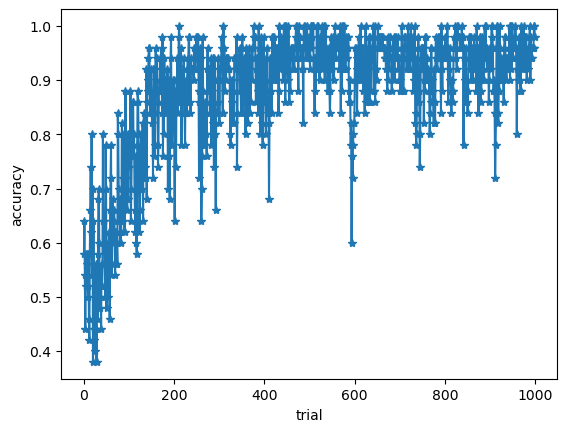

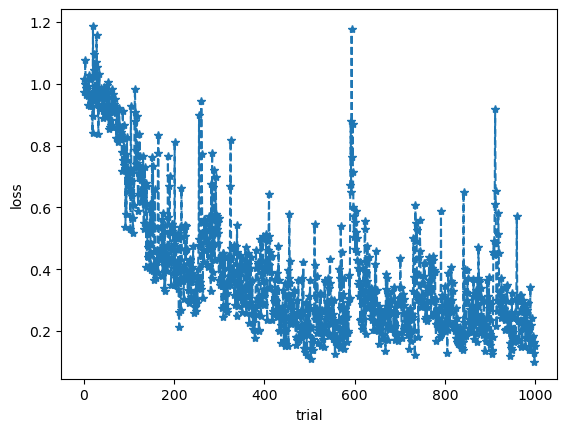

In [27]:
plt.figure()
plt.plot(epoch_acc, "-*")
plt.xlabel("trial")
plt.ylabel("accuracy")

epoch_loss = [epoch_loss[i].item() for i in range(len(epoch_loss))]
plt.figure()
plt.plot(epoch_loss, "--*")
plt.xlabel("trial")
plt.ylabel("loss")

r_final_arr.shape torch.Size([50000, 100, 750])


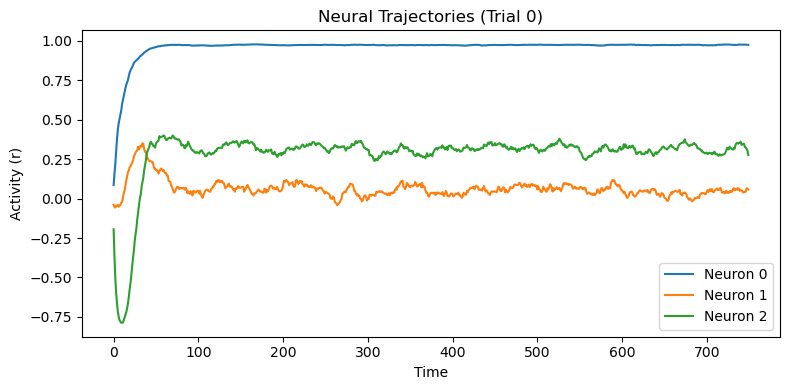

In [28]:
def plot_neural_trajectories(all_r, neuron_ids=[0,1,2], trial_id=0):
    r = all_r[trial_id,:,:].detach().cpu().numpy()  # shape (hidden, T)
    T = r.shape[1]

    plt.figure(figsize=(8,4))
    for nid in neuron_ids:
        plt.plot(range(T), r[nid,:], label=f"Neuron {nid}")
    
    plt.xlabel("Time")
    plt.ylabel("Activity (r)")
    plt.title(f"Neural Trajectories (Trial {trial_id})")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("r_final_arr.shape", r_final_arr.shape)
plot_neural_trajectories(r_final_arr)

In [29]:
y_ind0 = np.where(y == -1)[0]
y_ind1 = np.where(y == 1)[0]

context_ = y_dataset_full2[:,2]
context_ind0 = np.where(context_==-1)[0]
context_ind1 = np.where(context_==1)[0]

motion_ = y_dataset_full2[:,0]
motion_ind0 = np.where(motion_==-1)[0]
motion_ind1 = np.where(motion_==1)[0]

color_ = y_dataset_full2[:,1]
color_ind0 = np.where(color_==-1)[0]
color_ind1 = np.where(color_==1)[0]

In [30]:
def plot_pca_trajectories(all_r, trial_ids=[0,1], labels=None):
    # all_r: (batch, hidden, T)
    all_r = all_r.detach().cpu().numpy()

    plt.figure(figsize=(8,6))

    for idx, trial in enumerate(trial_ids):
        r = all_r[trial,:,:]  # (hidden, T)
        pca = PCA(n_components=3)
        traj = pca.fit_transform(r.T)  # (T, 3)

        ax = plt.subplot(111, projection='3d')
        ax.plot(traj[:,0], traj[:,1], traj[:,2], label=f"Trial {trial}")

        if labels is not None:
            ax.set_title(labels[trial])

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    #ax.legend()
    plt.tight_layout()
    plt.show()

def plot_pca_trajectories_2d(all_r, trial_ids=[0,1], labels=None):
    # all_r: (batch, hidden, T)
    all_r = all_r.detach().cpu().numpy()

    plt.figure(figsize=(8,6))
    traj_avg = np.zeros((all_r.shape[2],2))
    
    for idx, trial in enumerate(trial_ids):
        r = all_r[trial,:,:]  # (hidden, T)
        pca = PCA(n_components=2)
        traj = pca.fit_transform(r.T)  # (T, 3)

        ax = plt.subplot(111)
        ax.plot(traj[:,0], traj[:,1], label=f"Trial {trial}")

        traj_avg += traj;
        if labels is not None:
            ax.set_title(labels[trial])

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    #ax.legend()
    plt.tight_layout()
    plt.show()

    return traj_avg/len(trial_ids)

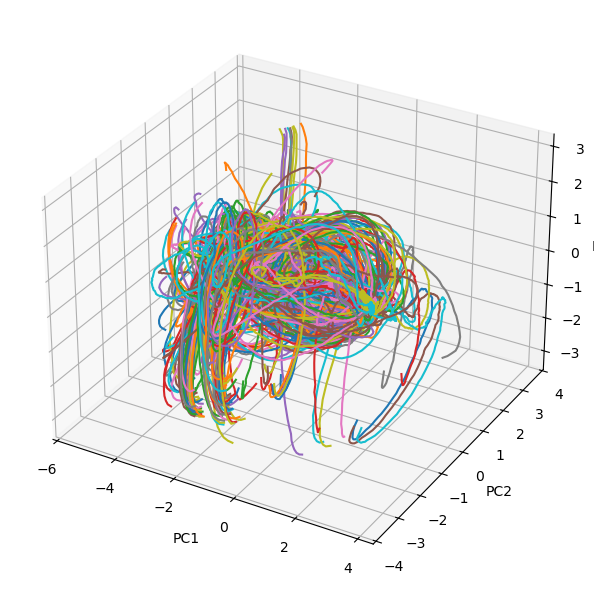

In [32]:
#list_of_trials = list(context_ind0[:100]) + list(context_ind1[:100])
list_of_trials = list(y_ind0[:100]) + list(y_ind1[:100]) #some trials choosing +1, some trials choosing -1
plot_pca_trajectories(all_r, trial_ids=list_of_trials)

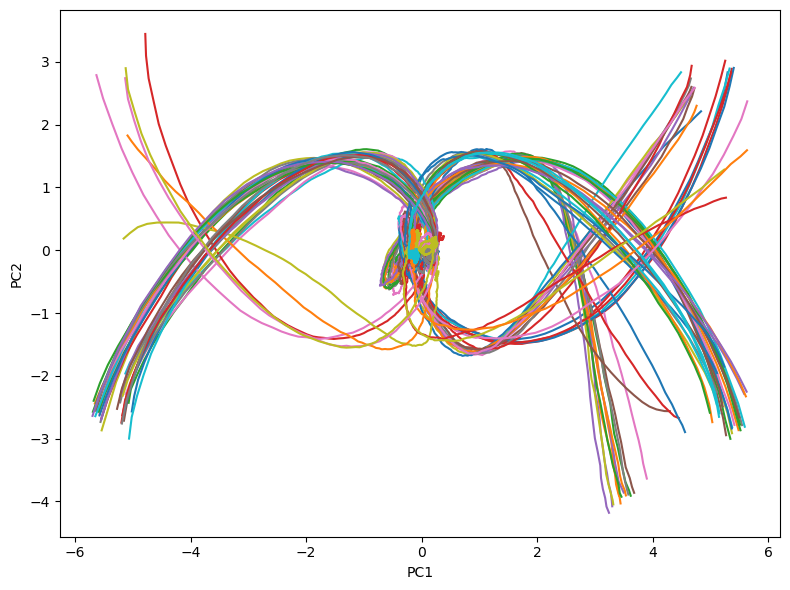

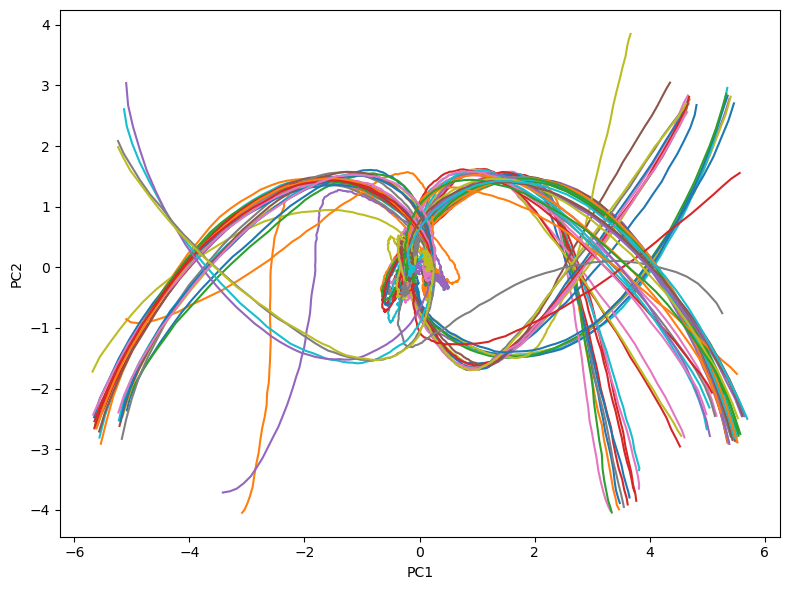

Text(0, 0.5, 'PC2')

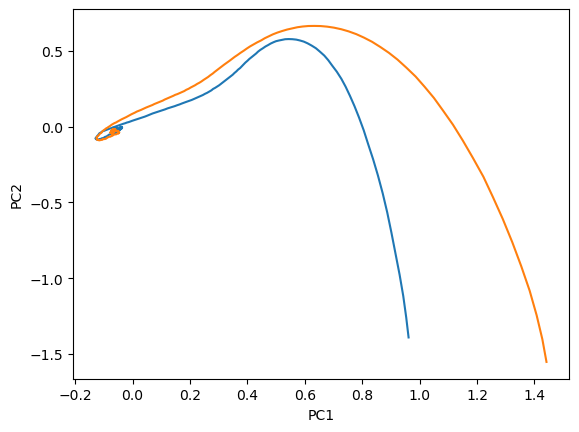

In [33]:
traj_avg1 = plot_pca_trajectories_2d(r_final_arr, trial_ids=y_ind0[:100])
traj_avg2 = plot_pca_trajectories_2d(r_final_arr, trial_ids=y_ind1[:100])

plt.plot(traj_avg1[:,0],traj_avg1[:,1]) 
plt.plot(traj_avg2[:,0],traj_avg2[:,1]) 
plt.xlabel("PC1")
plt.ylabel("PC2")

In [34]:
def compute_context_axis(all_r, X_input):
    """
    all_r: (batch, hidden, T)
    y_full: (batch, 3) -> (motion, color, context)
    """
    context = 2*np.where(X_input[:,2:3,0]==1)[0] - 1  # -1 or +1
    r = all_r.mean(dim=2)  # average over time (batch, hidden)

    r_ctx1 = r[context == 1].mean(dim=0)
    r_ctxm1 = r[context == -1].mean(dim=0)

    context_axis = r_ctx1 - r_ctxm1  # vector in hidden space
    context_axis = context_axis / context_axis.norm()

    return context_axis

In [35]:
def compute_choice_axes(model, all_r, y):
    
    # model.fc_out.weight: (1, hidden)
    choice_axis_model = model.fc_out.weight.data.squeeze(0)          # torch (H,)
    choice_axis_model = choice_axis_model / choice_axis_model.norm()

    # regression-based choice axis (fit final choice using population at final time)
    with torch.no_grad():
        R_final = all_r[:, :, -1].detach().cpu().numpy()   # (B, H)
        y_np = y.reshape(-1, 1)              # (B,1)
    # ridge to get direction in H space: solve R_final @ w = y
    ridge = Ridge(alpha=1.0, fit_intercept=False)
    ridge.fit(R_final, y_np)
    w = ridge.coef_.reshape(-1)    # shape (H,)
    w = w / np.linalg.norm(w)
    choice_axis_ridge = torch.from_numpy(w).float()

    return choice_axis_model.detach(), choice_axis_ridge


In [36]:
def project_and_summary(all_r, axis, y=None):
    # axis: torch (H,) or numpy (H,)
    if isinstance(axis, np.ndarray):
        axis = torch.from_numpy(axis).float()
    axis = axis.to(all_r.device)
    
    # project on the axis; proj: (B, T)
    #“At each time step, how much does the neural population point in the direction of this axis?”
    #proj[b,t] = sum_{h=1}^{H} all_r[b,h,t]⋅axis[h], ie sum over units in hidden layer
    proj = torch.einsum('bht,h->bt', all_r, axis)
    
    proj_np = proj.detach().cpu().numpy()

    print("proj_np.shape", proj_np.shape)
    #separate projectiom across trials for choice +1/-1, and take mean/std of projections
    mean_plus = proj_np[(y==1).cpu().numpy(),:].mean(axis=0) if y is not None else None
    mean_minus= proj_np[(y==-1).cpu().numpy(),:].mean(axis=0) if y is not None else None
    sem_plus  = proj_np[(y==1).cpu().numpy(),:].std(axis=0, ddof=1) / np.sqrt((y==1).sum().item()) if y is not None else None
    sem_minus = proj_np[(y==-1).cpu().numpy(),:].std(axis=0, ddof=1) / np.sqrt((y==-1).sum().item()) if y is not None else None

    T = mean_plus.shape[0]
    t = np.arange(T)
    plt.figure(figsize=(7,4))
    
    ind0 = np.where((y==-1).cpu().numpy())[0]
    ind0 = ind0[np.random.choice(len(ind0),100)] #ind0[-100:]
    ind1 = np.where((y==1).cpu().numpy())[0]
    ind1 = ind1[np.random.choice(len(ind1),100)] #ind1[-100:]
    plt.plot(t, proj_np[ind0, :].T, color='blue', alpha=0.2)
    plt.plot(t, proj_np[ind1,:].T, color = 'orange', alpha=0.2)
    plt.xlabel("Time")
    plt.ylabel("Projection")
   
    plt.figure()
    plt.fill_between(t, mean_minus-sem_minus, mean_minus+sem_minus, alpha=0.5, color='C0')
    plt.plot(t, mean_minus, label='-1', color='C0')
    plt.fill_between(t, mean_plus-sem_plus, mean_plus+sem_plus, alpha=0.5, color='C1')
    plt.plot(t, mean_plus, label='+1', color='C1')
    plt.xlabel('Time')
    plt.ylabel('Projection')
    plt.title('Projection over time')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return proj_np

proj_np.shape (1000, 750)


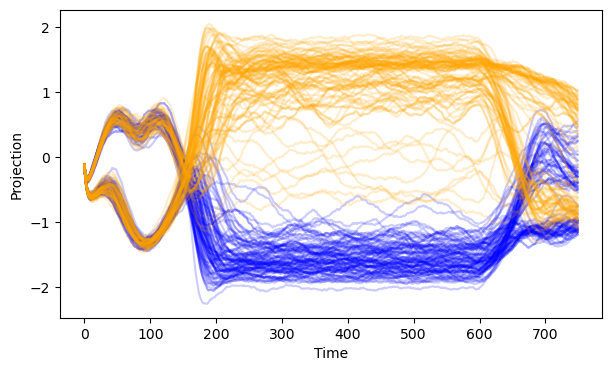

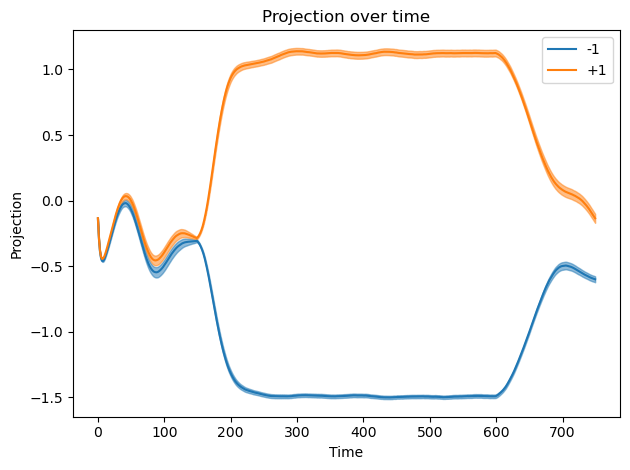

In [37]:
choice_axis_model, choice_axis_ridge = compute_choice_axes(model, all_r, y)
#context_axis = compute_context_axis(r_final_arr, X_arr)
proj_np = project_and_summary(all_r, choice_axis_model, y)

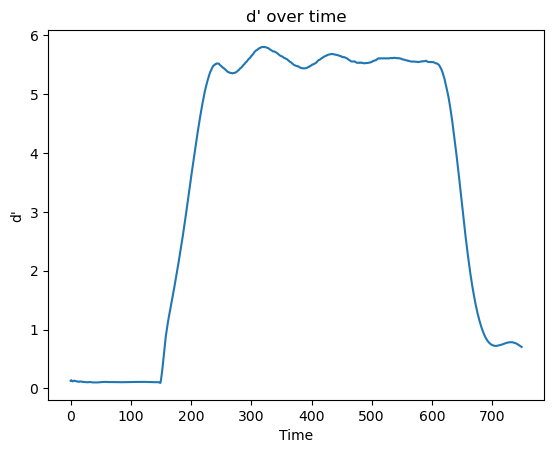

In [38]:
def compute_dprime_over_time(proj, y):
    # proj: (B, T)
    mu_p = proj[y==1].mean(axis=0)
    mu_m = proj[y==-1].mean(axis=0)
    var_p = proj[y==1].var(axis=0, ddof=1)
    var_m = proj[y==-1].var(axis=0, ddof=1)
    # pooled sd
    sd_pooled = np.sqrt(0.5*(var_p + var_m))
    dprime = (mu_p - mu_m) / (sd_pooled + 1e-10)
    return dprime

# --- 5) PCA on trial-averaged conditions and plotting 3D ---------------------

def trial_average_by_condition(all_r, y_dataset_full):
    # y_full[:,0]=motion,[:,1]=color,[:,2]=context
    motion = y_full[:,0].cpu().numpy()
    color  = y_full[:,1].cpu().numpy()
    context = y_full[:,2].cpu().numpy()
    conds = {}
    for m in [-1,1]:
        for c in [-1,1]:
            for ctx in [-1,1]:
                mask = (motion==m) & (color==c) & (context==ctx)
                if mask.sum() == 0:
                    continue
                # average over trials for that condition
                avg = all_r[mask].mean(dim=0).cpu().numpy()   # (H, T)
                conds[(m,c,ctx)] = avg
    return conds

dprime = compute_dprime_over_time(proj_np, y.cpu())
plt.figure(); plt.plot(dprime); plt.xlabel('Time'); plt.ylabel("d'"); plt.title("d' over time"); plt.show()


In [39]:
def trial_average_by_condition(all_r, y_full):
    # y_full[:,0]=motion,[:,1]=color,[:,2]=context
    motion = y_full[:,0].cpu().numpy()
    color  = y_full[:,1].cpu().numpy()
    context = y_full[:,2].cpu().numpy()
    conds = {}
    for m in [-1,1]:
        for c in [-1,1]:
            for ctx in [-1,1]:
                mask = (motion==m) & (color==c) & (context==ctx)
                if mask.sum() == 0:
                    continue

                # average over trials for that condition
                avg = all_r[mask].mean(dim=0).cpu().detach().numpy()   # (H, T) #average trajectory over each condition
                conds[(m,c,ctx)] = avg
    return conds

def pca_plot_condition_trajectories(cond_trajs, n_components=3):
    # stack and fit PCA on concatenated time X conditions
    trajs = []
    keys = []
    for k,v in cond_trajs.items():
        # v: (H, T) -> transpose to (T, H)
        trajs.append(v.T)
        keys.append(k)

    big = np.concatenate(trajs, axis=0)   # (T*conds, H)
    print("trajs.shape", big.shape)

    pca = PCA(n_components=n_components)
    big_p = pca.fit_transform(big)        # (T*conds, n_components)
    print("big_p.shape", big_p.shape)
        
    # split back and plot
    idx = 0
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    for k,v in zip(keys, trajs):
        T = v.shape[0]
        seg = big_p[idx:idx+T]
        ctx = k[2]
        color = 'C0' if ctx==-1 else 'C1'
        ax.plot(seg[:,0], seg[:,1], seg[:,2], color=color, alpha=0.9)
        idx += T
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    plt.title('Condition-averaged PCA trajectories')
    plt.show()

trajs.shape (6000, 100)
big_p.shape (6000, 3)


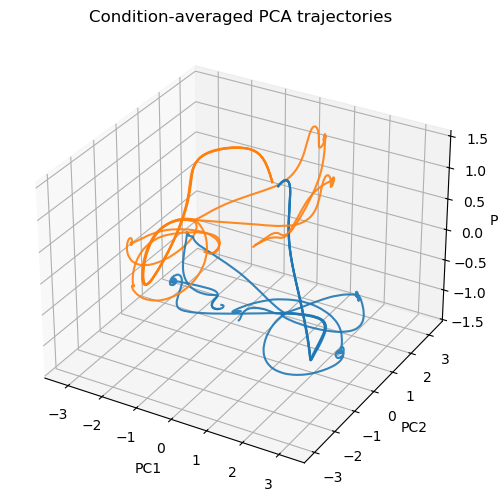

In [40]:
conds = trial_average_by_condition(all_r, y_dataset_full2)
pca_plot_condition_trajectories(conds)


In [41]:
"""
# --- 6) endpoint scatter in 2D (PC1-PC2) -----------------------------------
def endpoint_scatter(R_pca, y_full):
    endpoints = R_pca[:, -1, :2]
    ctx = y_full[:,2].cpu().numpy()
    plt.figure(figsize=(6,5))
    plt.scatter(endpoints[ctx==-1,0], endpoints[ctx==-1,1], label='motion ctx', alpha=0.7)
    plt.scatter(endpoints[ctx== 1,0], endpoints[ctx== 1,1], label='color ctx', alpha=0.7)
    plt.legend()
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Endpoints (PC1-PC2)')
    plt.show()


B,H,T = r_final_arr[-10000:,:,:].shape
R_flat = r_final_arr[-10000:,:,:].cpu().detach().numpy().transpose(0,2,1).reshape(-1, H)
pca = PCA(n_components=3)
R_pca_flat = pca.fit_transform(R_flat)
R_pca = R_pca_flat.reshape(B, T, 3)
endpoint_scatter(R_pca, y_dataset_full)
"""

"\n# --- 6) endpoint scatter in 2D (PC1-PC2) -----------------------------------\ndef endpoint_scatter(R_pca, y_full):\n    endpoints = R_pca[:, -1, :2]\n    ctx = y_full[:,2].cpu().numpy()\n    plt.figure(figsize=(6,5))\n    plt.scatter(endpoints[ctx==-1,0], endpoints[ctx==-1,1], label='motion ctx', alpha=0.7)\n    plt.scatter(endpoints[ctx== 1,0], endpoints[ctx== 1,1], label='color ctx', alpha=0.7)\n    plt.legend()\n    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Endpoints (PC1-PC2)')\n    plt.show()\n\n\nB,H,T = r_final_arr[-10000:,:,:].shape\nR_flat = r_final_arr[-10000:,:,:].cpu().detach().numpy().transpose(0,2,1).reshape(-1, H)\npca = PCA(n_components=3)\nR_pca_flat = pca.fit_transform(R_flat)\nR_pca = R_pca_flat.reshape(B, T, 3)\nendpoint_scatter(R_pca, y_dataset_full)\n"

In [ ]:
#compute axes of motion, color, choice, and context like in the paper

In [131]:
def compute_betas(all_r, y_full,y):
    # all_r: (B, H, T)
    B, H, T = all_r.shape
    betas = np.zeros((T, H, 4))  # choice, motion, color, context

    choice  = y.cpu().numpy()
    motion  = y_full[:,0].cpu().numpy()
    color   = y_full[:,1].cpu().numpy()
    context = y_full[:,2].cpu().numpy()
    #constant = torch.ones_like(y).cpu().numpy()
    
    X = np.stack([choice, motion, color, context], axis=1)

    for t in range(T):
        for h in range(H):
            y = all_r[:,h,t].cpu().detach().numpy()
            reg = LinearRegression().fit(X, y)
            betas[t,h,:] = reg.coef_[:4]

    return betas

def max_norm_axes(betas):
    # betas: (T, H, 4)
    axes = []
    for k in range(4):
        norms = np.linalg.norm(betas[:,:,k], axis=1)
        t_star = norms.argmax()
        axes.append(betas[t_star,:,k])
    return np.stack(axes)

betas = compute_betas(all_r, y_dataset_full2, y_dataset2[:,750//2])
print("betas.shape", betas.shape)

beta_axes = max_norm_axes(betas)

Q, R = qr(beta_axes.T)
axes_orth = Q.T

betas.shape (750, 100, 4)


In [132]:
axes_orth.shape, all_r.shape, y_dataset_full2.shape, y_dataset2.shape

((4, 100),
 torch.Size([1000, 100, 750]),
 torch.Size([1000, 3]),
 torch.Size([1000, 750]))

In [135]:
#what is the angle between the choice axis that is computed above after orthogonalization, and the choice axis given by the model's weights?
beta_choice = axes_orth[0]

w_out = model.fc_out.weight.detach().cpu().numpy().reshape(-1)
w_out = w_out / np.linalg.norm(w_out)

beta_choice = beta_choice / np.linalg.norm(beta_choice)

print("cos(readout, choice axis):", np.dot(w_out, beta_choice))


cos(readout, choice axis): -0.5690206718474621


In [136]:
def project_and_summary(all_r, axis, y=None, to_plot=[0,1], col=0, supress = False):
    # axis: torch (H,) or numpy (H,)
    if isinstance(axis, np.ndarray):
        axis = torch.from_numpy(axis).float()
    axis = axis.to(all_r.device)
    N, hidden_u, T = all_r.shape
    
    # project on the axis; proj: (B, T)
    #“At each time step, how much does the neural population point in the direction of this axis?”
    #proj[b,t] = sum_{h=1}^{H} all_r[b,h,t]⋅axis[h], ie sum over units in hidden layer

    print("all_r.shape", all_r.shape, axis.shape)
    print(np.transpose(axis, (1,0)).shape)

    #proj = torch.einsum('bht,h->bt', all_r, axis)
    r_btH = all_r.transpose(1, 2)   # [B, T, H]
    axis = axis.transpose(1,0)
    proj = torch.matmul(r_btH, axis)  # [B, T, 4]
    proj_np = proj.detach().cpu().numpy()

    #separate projectiom across trials for choice +1/-1, and take mean/std of projections
    mean_plus = proj_np[(y==1).cpu().numpy(),:,:].mean(axis=0) if y is not None else None
    mean_minus= proj_np[(y==-1).cpu().numpy(),:,:].mean(axis=0) if y is not None else None
    sem_plus  = proj_np[(y==1).cpu().numpy(),:,:].std(axis=0, ddof=1) / np.sqrt((y==1).sum().item()) if y is not None else None
    sem_minus = proj_np[(y==-1).cpu().numpy(),:,:].std(axis=0, ddof=1) / np.sqrt((y==-1).sum().item()) if y is not None else None

    T = mean_plus.shape[0]
    t = np.arange(T)
    plt.figure(figsize=(7,4))

    ind0 = np.where((y==-1).cpu().numpy())[0]
    ind1 = np.where((y==1).cpu().numpy())[0]

    axis_names = []
    if 0 in to_plot:
        axis_names.append("choice axis")
    if 1 in to_plot:
        axis_names.append("motion axis")
    if 2 in to_plot:
        axis_names.append("color axis")
    if 3 in to_plot:
        axis_names.append("context axis")

    plt.figure()
    if len(ind0) != 0:
        ind0 = ind0[np.random.choice(len(ind0),10)] #ind0[-100:]
        plt.plot(proj_np[ind0, int(0.2*T):int(0.8*T), to_plot[0]].T, proj_np[ind0, int(0.2*T):int(0.8*T), to_plot[1]].T, color = "C" + str(col))

    if len(ind1) != 0:
        ind1 = ind1[np.random.choice(len(ind1),10)] #ind1[-100:]
        plt.plot(proj_np[ind1, int(0.2*T):int(0.8*T), to_plot[0]].T, proj_np[ind1, int(0.2*T):int(0.8*T), to_plot[1]].T, color = "C" + str(col+1))
    plt.xlabel(axis_names[0])
    plt.ylabel(axis_names[1])

    if supress == False:
        plt.figure()
        print("mean_minus, sem_minus", mean_minus.shape, sem_minus.shape)
        plt.fill_between(t, mean_minus[:,0]-sem_minus[:,0], mean_minus[:,0]+sem_minus[:,0], alpha=0.5, color='C1')
        plt.plot(t, mean_minus[:,0], label='-1', color='C1')
        plt.fill_between(t, mean_plus[:,0]-sem_plus[:,0], mean_plus[:,0]+sem_plus[:,0], alpha=0.5, color='C0')
        plt.plot(t, mean_plus[:,0], label='+1', color='C0')
        plt.xlabel('Time')
        plt.ylabel('Projection')
        plt.title('Projection over time')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return proj_np

all_r.shape torch.Size([1000, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])
mean_minus, sem_minus (750, 4) (750, 4)


<Figure size 700x400 with 0 Axes>

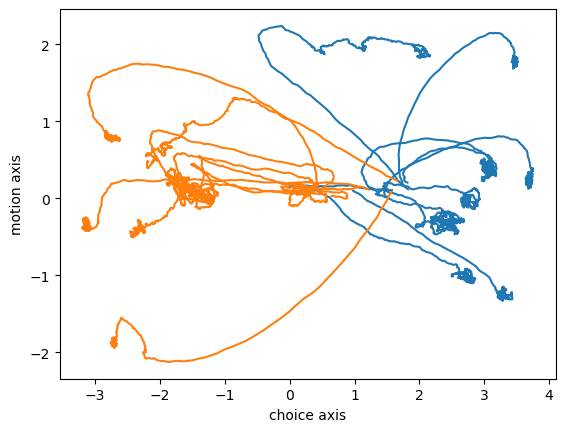

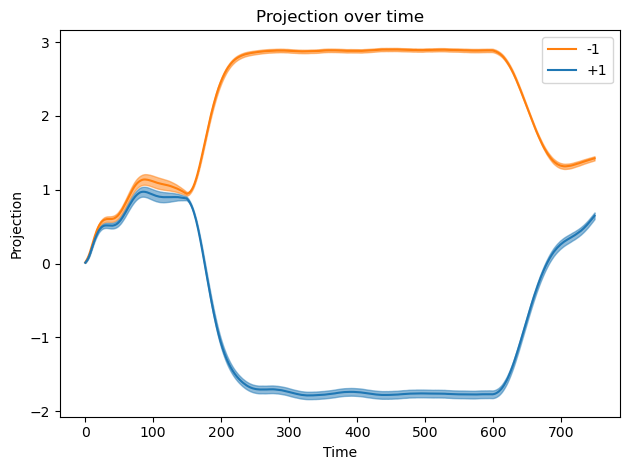

In [137]:
proj = project_and_summary(all_r, axes_orth, y)

all_r.shape torch.Size([479, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])
all_r.shape torch.Size([479, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])


<Figure size 700x400 with 0 Axes>

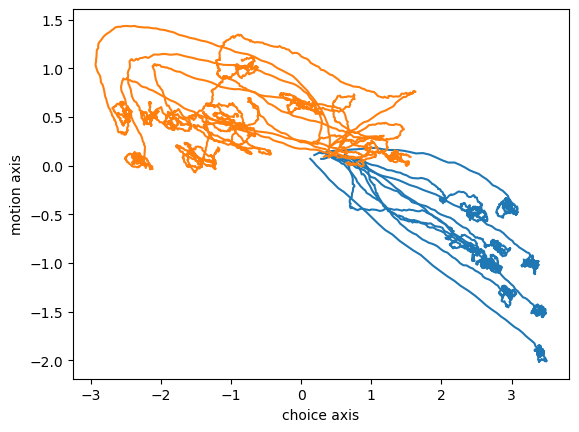

<Figure size 700x400 with 0 Axes>

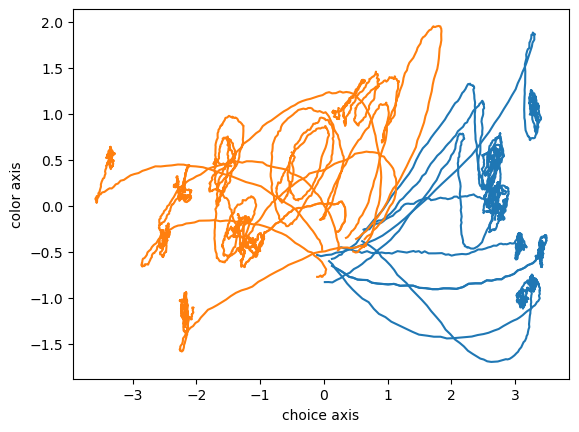

In [138]:
#look at dynamics, motion context
ind_to_plot0 = list(set(motion_ind0) & set(context_ind0))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind0))

proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], supress = True)
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,2], supress = True)



all_r.shape torch.Size([521, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])
all_r.shape torch.Size([521, 100, 750]) torch.Size([4, 100])
torch.Size([100, 4])


<Figure size 700x400 with 0 Axes>

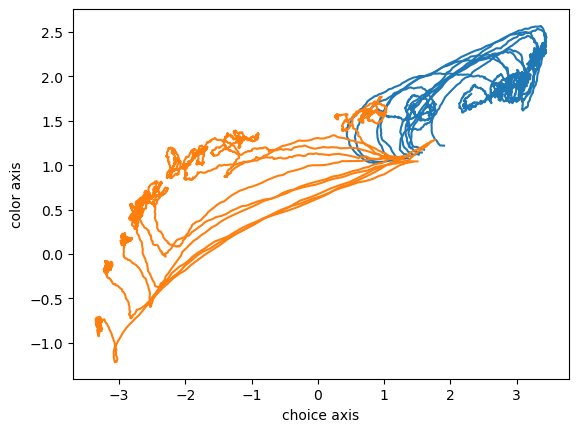

<Figure size 700x400 with 0 Axes>

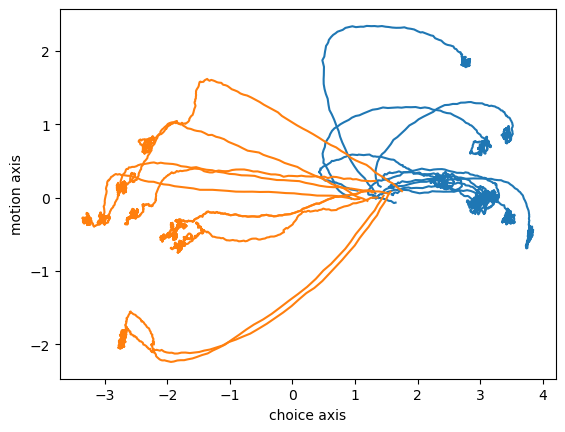

In [139]:
#look at dynamics, color context
ind_to_plot0 = list(set(color_ind0) & set(context_ind1))
ind_to_plot1 = list(set(color_ind1) & set(context_ind1))
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,2], supress=True)
proj = project_and_summary(all_r[ind_to_plot0+ind_to_plot1, :, :], axes_orth, y[ind_to_plot0+ind_to_plot1], to_plot=[0,1], supress=True)


In [49]:
#Section : Compute fixed points

In [114]:
#model vector field that gives loss function to find fixed point
def model_vector_field(h, x_const, model):
    """
    Computes F(h) = -h + J tanh(h) + Bx + b
    """

    r = model.nonlinear_fn(h)
    # J r  (shape: hidden_size)
    Jr = r @ model.J_weights.T

    # B x  (shape: hidden_size)
    Bx = model.fc_in(x_const)

    # F(h)
    F = -h + Jr + Bx + model.bias

    return F

In [115]:
#optimization to find fixed point
def find_fixed_point(X, all_h, model, trial, time_idx, max_iter=1000, tol=1e-8):

    # initial guess from trajectory
    h = all_h[trial, :, time_idx].clone().detach().requires_grad_(True)

    # hold input fixed at this timestep
    x_const = X[trial, :, time_idx]

    #optimization
    optimizer = torch.optim.Adam([h], lr=1e-2)
    loss_arr = []; h_star_arr = []
    for i in range(max_iter):

        F = model_vector_field(h, x_const, model)
        loss = (F**2).sum() #minimizing (-h + J*r + Bx +bias)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Iter {i}, loss = {loss.item():.3e}")

        #until loss is very small
        if loss.item() < tol:
            break

        loss_arr.append(loss.item()); h_star_arr.append(h.detach().cpu().clone().numpy())
    h_star = h.detach()
    r_star = model.nonlinear_fn(h_star)

    return h_star, r_star, loss.item(), loss_arr, h_star_arr

In [116]:
h_star, r_star, final_loss, loss_arr, h_star_arr = find_fixed_point(X=X, all_h=all_h, model=model, trial=0, time_idx=int(0.75 * 750))
print("final FP loss:", final_loss)

Iter 0, loss = 1.241e-01
Iter 100, loss = 9.312e-06
final FP loss: 9.451841975760544e-09


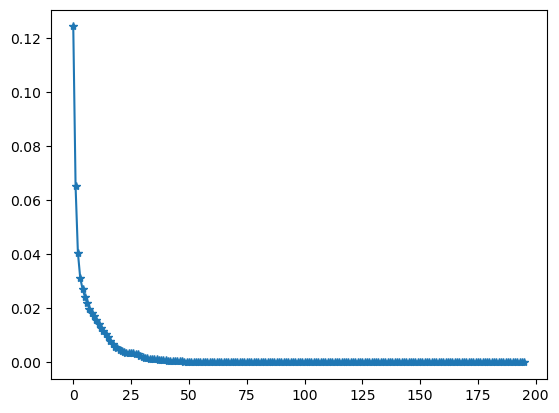

In [117]:
plt.plot(loss_arr, "*-")

Text(0.5, 1.0, 'zoom in around fixed point')

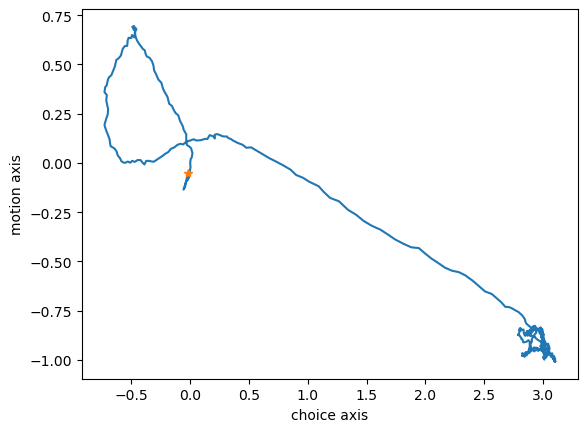

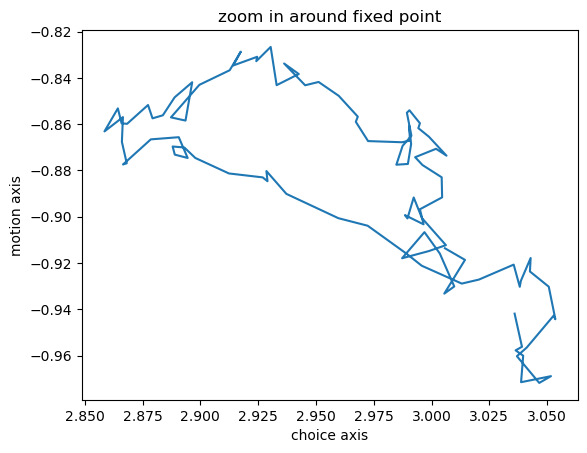

In [118]:
#plot a trajectory (as well as zoomed-in version near fixed point)
trial = 0
rr = model.nonlinear_fn(all_h[trial,:,:])
proj_rr = torch.matmul(rr.T.float(), torch.from_numpy(axes_orth.T).float())
plt.plot(proj_rr[:int(0.7*750),0].detach().numpy(), proj_rr[:int(0.7*750),1].detach().numpy())
plt.plot(proj_rr[0,0].detach().numpy(), proj_rr[0,1].detach().numpy(), "*")
plt.xlabel("choice axis")
plt.ylabel("motion axis")

#zoom in
plt.figure()
plt.plot(proj_rr[int(0.7*750)-100:int(0.7*750),0].detach().numpy(), proj_rr[int(0.7*750)-100:int(0.7*750),1].detach().numpy())
plt.xlabel("choice axis")
plt.ylabel("motion axis")
plt.title("zoom in around fixed point")

Text(0, 0.5, 'motion axis')

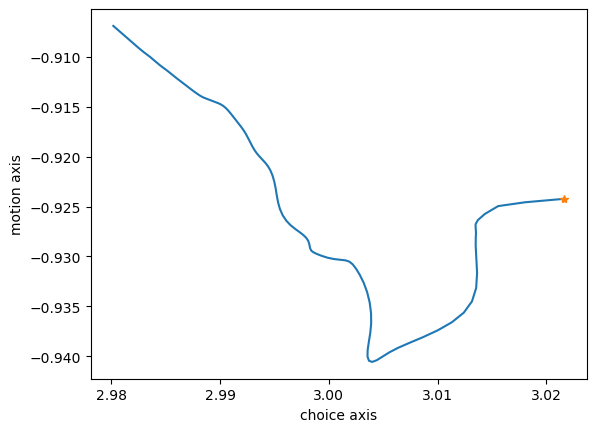

In [119]:
#now look around computed fixed point
h_star_arr = np.stack(h_star_arr)
rr = model.nonlinear_fn(torch.from_numpy(h_star_arr))
proj_rr = torch.matmul(rr.float(), torch.from_numpy(axes_orth.T).float())

plt.plot(proj_rr[:int(0.7*750),0].detach().numpy(), proj_rr[:int(0.7*750),1].detach().numpy())
plt.plot(proj_rr[0,0].detach().numpy(), proj_rr[0,1].detach().numpy(), "*")
plt.xlabel("choice axis")
plt.ylabel("motion axis")

In [120]:
#compute fixed points for all trials in the testing set
proj_star_arr = []
for i in range(len(X)):
    print(i)
    h_star, r_star, final_loss, loss_arr, h_star_arr = find_fixed_point(X, all_h, model, i, time_idx=int(0.7 * 750))
    r_star = model.nonlinear_fn(h_star)

    proj_star = torch.matmul(r_star.float(), torch.from_numpy(axes_orth.T).float())
    proj_star_arr.append(proj_star)

proj_star_arr = torch.stack(proj_star_arr)

0
Iter 0, loss = 1.454e-01
Iter 100, loss = 1.616e-06
1
Iter 0, loss = 1.560e-01
Iter 100, loss = 8.626e-05
Iter 200, loss = 3.569e-05
Iter 300, loss = 1.876e-05
Iter 400, loss = 8.753e-06
Iter 500, loss = 3.667e-06
Iter 600, loss = 2.146e-06
Iter 700, loss = 4.704e-07
Iter 800, loss = 3.781e-07
Iter 900, loss = 3.034e-06
2
Iter 0, loss = 1.232e-01
Iter 100, loss = 1.398e-05
Iter 200, loss = 9.303e-08
3
Iter 0, loss = 1.717e-01
Iter 100, loss = 1.101e-04
Iter 200, loss = 5.402e-06
Iter 300, loss = 7.001e-08
4
Iter 0, loss = 1.128e-01
Iter 100, loss = 1.092e-06
5
Iter 0, loss = 1.484e-01
Iter 100, loss = 6.284e-05
Iter 200, loss = 1.416e-07
6
Iter 0, loss = 1.025e-01
Iter 100, loss = 1.099e-05
7
Iter 0, loss = 1.291e-01
Iter 100, loss = 9.378e-05
Iter 200, loss = 1.890e-05
Iter 300, loss = 2.266e-06
Iter 400, loss = 3.191e-07
Iter 500, loss = 1.986e-07
8
Iter 0, loss = 1.229e-01
Iter 100, loss = 1.082e-04
Iter 200, loss = 1.014e-05
Iter 300, loss = 4.625e-07
9
Iter 0, loss = 9.895e-02
I

Text(0, 0.5, 'motion axis')

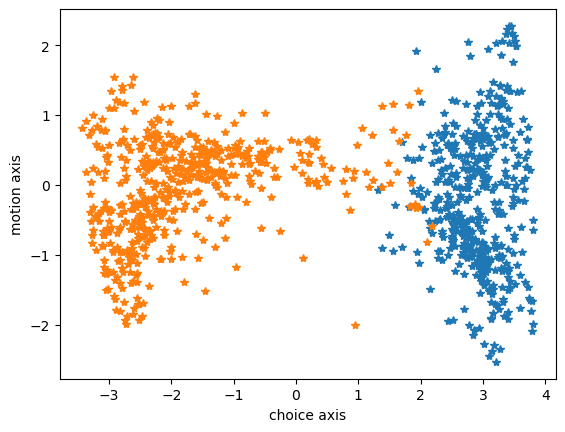

In [121]:
#plot all fixed point for labels +/-1
plt.plot(proj_star_arr[y_ind0,0], proj_star_arr[y_ind0,1], "*")
plt.plot(proj_star_arr[y_ind1,0], proj_star_arr[y_ind1,1], "*")
plt.xlabel("choice axis")
plt.ylabel("motion axis")

Text(0, 0.5, 'motion axis')

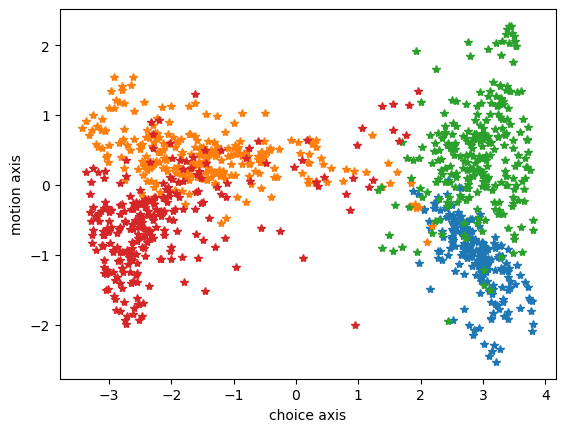

In [122]:
#plot all fixed point for motion +/-1 and motion context
ind_to_plot0 = list(set(motion_ind0) & set(context_ind0))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind0))

plt.plot(proj_star_arr[ind_to_plot0,0], proj_star_arr[ind_to_plot0,1], "*")
plt.plot(proj_star_arr[ind_to_plot1,0], proj_star_arr[ind_to_plot1,1], "*")

#plot all fixed point for color +/-1 and color context
ind_to_plot0 = list(set(color_ind0) & set(context_ind1))
ind_to_plot1 = list(set(color_ind1) & set(context_ind1))

plt.plot(proj_star_arr[ind_to_plot0,0], proj_star_arr[ind_to_plot0,1], "*")
plt.plot(proj_star_arr[ind_to_plot1,0], proj_star_arr[ind_to_plot1,1], "*")

plt.xlabel("choice axis")
plt.ylabel("motion axis")

Text(0, 0.5, 'color axis')

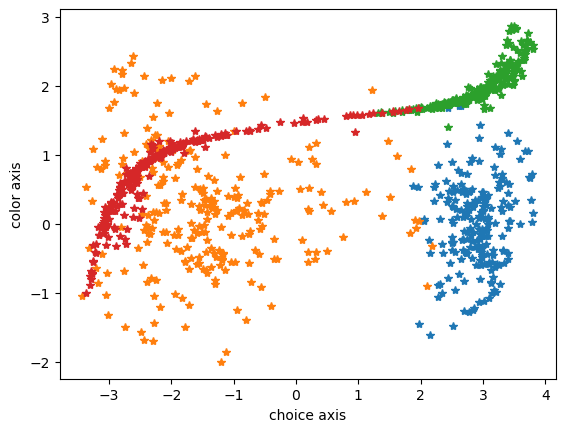

In [123]:
#plot all fixed points as before, but on choice axis and color axis
ind_to_plot0 = list(set(motion_ind0) & set(context_ind0))
ind_to_plot1 = list(set(motion_ind1) & set(context_ind0))

plt.plot(proj_star_arr[ind_to_plot0,0], proj_star_arr[ind_to_plot0,2], "*")
plt.plot(proj_star_arr[ind_to_plot1,0], proj_star_arr[ind_to_plot1,2], "*")

ind_to_plot0 = list(set(color_ind0) & set(context_ind1))
ind_to_plot1 = list(set(color_ind1) & set(context_ind1))

plt.plot(proj_star_arr[ind_to_plot0,0], proj_star_arr[ind_to_plot0,2], "*")
plt.plot(proj_star_arr[ind_to_plot1,0], proj_star_arr[ind_to_plot1,2], "*")

plt.xlabel("choice axis")
plt.ylabel("color axis")

In [ ]:
#Section : infer stability at fixed points

In [62]:
#linearize around a fixed point by computing the jacobian and its eigenvalues. Thus, detemrine stability using the evalues
def jacobian_and_eigs_at_fp(model, h_star, x_const=None, return_all=False, device='cpu'):
    """
    Linearize dynamics around fixed points
    Compute Jacobian of F(h) = -h + J tanh(h) + B x + b at h_star,
    and return eigenvalues and diagnostics.
    """
    
    # ensure on device and correct shape
    h = h_star.clone().detach().to(device).reshape(-1)
    N = h.numel()

    # ensure model matrices on same device & detach to numpy later
    J = model.J_weights.detach().to(device)       # shape [N, N]
    b = model.bias.detach().to(device).reshape(-1)   # shape [N,]

    # compute r* = tanh(h*)
    r = torch.tanh(h)

    # phi = 1 - r^2
    phi = (1.0 - r**2).reshape(-1)   # shape [N,]

    # build diag(phi) as a (N,N) tensor
    D = torch.diag(phi)   # (N,N)

    # Jacobian: -I + J @ D  (matches dF/dh_i_k = -delta_ik + J_ik * phi_k)
    I = torch.eye(N, device=device)
    Jc = -I + J @ D   # (N,N), continuous-time Jacobian

    # convert to numpy for eigendecomposition (move to cpu first)
    Jc_np = Jc.cpu().numpy()

    # eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eig(Jc_np)   # eigvals complex

    # discrete map eigenvalues for your update h_new = h + s * F(h)
    s = float(model.dt) / float(model.tau)
    M_np = np.eye(N) + s * Jc_np
    mu_vals, mu_vecs = np.linalg.eig(M_np)

    # diagnostics
    max_real = eigvals.real.max()
    spectral_radius = np.max(np.abs(eigvals))
    num_unstable_cont = (eigvals.real > 0).sum()          # eigenvalues with positive real part
    num_unstable_disc = (np.abs(mu_vals) > 1.0).sum()     # discrete update unstable modes

    report = {
        'N': N,
        's': s,
        'max_real_part_continuous': float(max_real),
        'spectral_radius_continuous': float(spectral_radius),
        'num_unstable_continuous': int(num_unstable_cont),
        'num_unstable_discrete': int(num_unstable_disc),
        'eigvals_continuous_sample': eigvals[:10],   # first few (for quick glance)
        'mu_vals_discrete_sample': mu_vals[:10],
    }

    if return_all:
        return Jc, eigvals, eigvecs, mu_vals, mu_vecs, report
    else:
        return eigvals, mu_vals, report

Iter 0, loss = 1.454e-01
Iter 100, loss = 1.616e-06
max real part (continuous): -0.1248360350728035
num unstable (continuous, Re>0): 0
num unstable (discrete, |mu|>1): 0


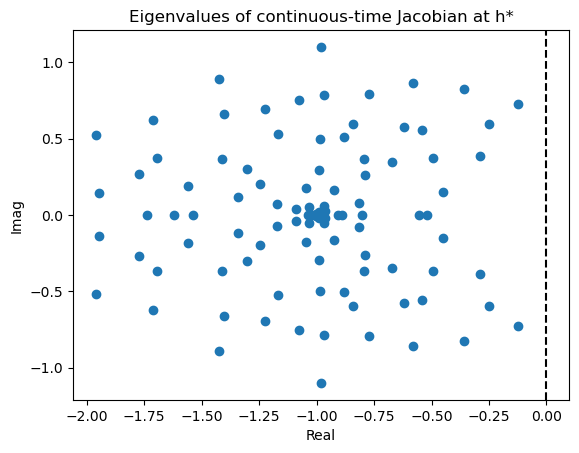

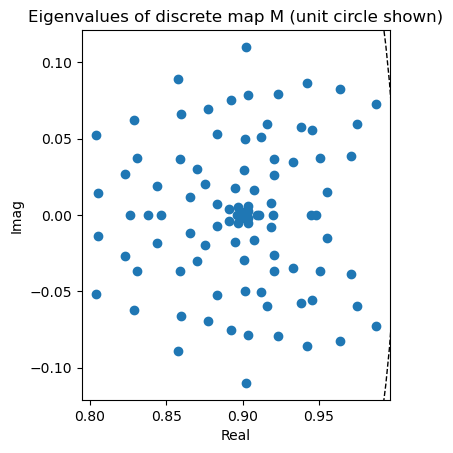

In [70]:
trial = 0
h_star, r_star, final_loss, loss_arr, h_star_arr = find_fixed_point(X, all_h, model, trial, time_idx=int(0.7 * model.T))
x_const = X[trial,:,int(model.T*0.8)-10]

Jc, eigvals, eigvecs, mu_vals, mu_vecs, report = jacobian_and_eigs_at_fp(model, h_star, x_const=x_const, device='cpu', return_all=True)
print("max real part (continuous):", report['max_real_part_continuous'])
print("num unstable (continuous, Re>0):", report['num_unstable_continuous'])
print("num unstable (discrete, |mu|>1):", report['num_unstable_discrete'])

# to inspect eigenvalues more:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(eigvals_cont.real, eigvals_cont.imag)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Eigenvalues of continuous-time Jacobian at h*')

plt.figure()
plt.scatter(eigvals_disc.real, eigvals_disc.imag)
circle = plt.Circle((0,0), 1.0, color='k', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Eigenvalues of discrete map M (unit circle shown)')
plt.gca().set_aspect('equal', 'box')
plt.show()


In [71]:
eigvals_real = eigvals_disc.real
print("Top 10 eigenvalues:", np.sort(eigvals_real)[::-1][:10])
#top evalues close to 1 => slow stable manifold in the direction of the eigenvector
#how does the eigenvector direction compare to the choice axis direction?

Top 10 eigenvalues: [0.9875164  0.9875164  0.97512307 0.97512307 0.97129614 0.97129614
 0.96396013 0.96396013 0.955165   0.955165  ]


In [93]:
lambda_F

(-1.2483604+7.2945075j)

In [94]:
s = model.dt / model.tau

# 2) find slowest (least negative real part) lambda_F
eigvals_F = model.tau * eigvals_cont
eigvecs_F = eigvecs
idx = np.argmax(eigvals_F.real)   # index of maximum real part (closest to zero)
lambda_F = eigvals_F[idx]
mu = eigvals_disc[idx]

print("lambda_F (closest to zero):", lambda_F)
print("corresponding discrete mu (should equal 1 + s*lambda_F):", mu, "calc:", 1 + s*lambda_F)

# 3) continuous time eigenvalue and time constant
lambda_cont = lambda_F / model.tau
tau_decay_cont = -1.0 / lambda_cont.real
tau_decay_disc = -model.dt / np.log(mu.real)   # use real part if mu is real; if complex use abs(mu)
print("lambda_cont:", lambda_cont, "tau_decay (cont):", tau_decay_cont, "tau_decay (disc):", tau_decay_disc)

# 4) eigenvector alignment with choice axis and readout
# eigvecs_F from numpy eigvecs (shape N x N), get eigenvector:
v = eigvecs_F[:, idx]   # complex
v_real = np.real(v)     # principal direction (could also use magnitude)
# normalize
v_unit = v_real / (np.linalg.norm(v_real) + 1e-12)

# compute cosine with choice axis and readout
cos_choice = np.dot(v_unit, axes_orth[0,:]) / (np.linalg.norm(axes_orth[0,:])+1e-12)
cos_readout = np.dot(v_unit, model.fc_out.weight.reshape(-1).detach().numpy()) / (np.linalg.norm(model.fc_out.weight.reshape(-1).detach().numpy())+1e-12)
print("cosine with choice axis:", cos_choice, "cosine with readout:", cos_readout)

lambda_F (closest to zero): (-1.2483604+7.2945075j)
corresponding discrete mu (should equal 1 + s*lambda_F): (0.9875163973054742+0.07294507696702486j) calc: (0.8751639604568482+0.7294507503509522j)
lambda_cont: (-0.12483603954315187+0.7294507503509522j) tau_decay (cont): 8.010507251428235 tau_decay (disc): 79.60403375275868
cosine with choice axis: -0.2582411600871501 cosine with readout: -0.013886021417808389


In [97]:
axes_orth.shape, model.fc_out.weight.reshape(-1).shape, eigvecs.shape

((4, 100), torch.Size([100]), (100, 100))

In [142]:
# 1) get the eigenvector (real part)
idx_slow=1
v_h = np.real(eigvecs_F[:, idx_slow])
v_h = v_h / (np.linalg.norm(v_h) + 1e-12)

# 2) convert to r-space using phi = 1 - tanh(h_star)^2
h_np = h_star.detach().cpu().numpy().reshape(-1)
phi = 1.0 - np.tanh(h_np)**2   # shape (N,)
v_r = phi * v_h
v_r = v_r / (np.linalg.norm(v_r) + 1e-12)

# 3) normalize axes you're comparing
beta_choice_unit = axes_orth[0,:] / (np.linalg.norm(axes_orth[0,:]) + 1e-12)
w_out_unit = model.fc_out.weight.reshape(-1).detach().numpy() / (np.linalg.norm(model.fc_out.weight.detach().numpy()) + 1e-12)

# 4) cosine similarities
cos_choice = np.dot(v_r, beta_choice_unit)
cos_readout = np.dot(v_r, w_out_unit)

print("cosine (slow eig in r-space, choice axis) :", cos_choice)
print("cosine (slow eig in r-space, readout)      :", cos_readout)

# 5) optional: compare with centroid difference of +1 / -1 FPs in r-space
# fps_r should be r* values; if you have them:
if 'fps' in globals():
    cent_pos = fps[labels_fp==1].mean(0)
    cent_neg = fps[labels_fp==-1].mean(0)
    fp_diff = (cent_pos - cent_neg)
    fp_diff = fp_diff / (np.linalg.norm(fp_diff) + 1e-12)
    print("cosine (slow eig in r-space, fp_diff)      :", np.dot(v_r, fp_diff))

cosine (slow eig in r-space, choice axis) : -0.25202451981234536
cosine (slow eig in r-space, readout)      : 0.0010958221


In [105]:
w_out = model.fc_out.weight.detach().cpu().numpy().reshape(-1)

# normalize
w_out = w_out / np.linalg.norm(w_out)

# regression-based choice axis, normalize
beta = axes_orth[0,:] / (np.linalg.norm(axes_orth[0,:]) + 1e-12)

# cosine between readout and your choice axis
print("cos(readout, choice axis):", np.dot(w_out, beta))

cos(readout, choice axis): -0.48051980038398245


In [106]:
axes_orth.shape

(4, 100)